In [1]:
from helpers import *

import os
import re
import numpy as np
import matplotlib. pyplot as plt
from scipy.spatial.distance import directed_hausdorff

In [2]:
nubmer_points_list= [100, 200,300,400,500,600,700,800,900,1000,1100,1200, 1300,1400,1500]
n_runs= [10]

In [3]:
def calculate_distance(point1, point2):
    return sum((x - y) ** 2 for x, y in zip(point1, point2)) ** 0.5

def calculate_tolerance(points):
    num_points = len(points)
    tolerance = 1/num_points
    return tolerance
    
def count_repeated_points(points):
    #points = points[np.lexsort((points[:, 1], points[:, 0]))]
    n= len(points)
    ep=  calculate_tolerance(points)
    distinct_points = []

    for point in points:
        is_distinct = True
        for distinct_point in distinct_points:
            if calculate_distance(point, distinct_point) < ep:
                is_distinct = False
                break
        if is_distinct:
            distinct_points.append(point)
            
    return len(distinct_points), distinct_points

In [4]:
import os

def list_txt_files_in_directory(directory_path):
    files_and_directories = os.listdir(directory_path)
    txt_files = [file for file in files_and_directories if file.endswith('.txt')]
    txt_files = [file for file in txt_files if '.txt' in file]
    txt_files.sort()
    txt_files= [directory_path+"/"+file for file in txt_files]
        
    return txt_files

In [5]:
eps_t= 1e-5
def get_accuracy(setXYP):
    acc= 0.0
    for i in range(len(setXYP)):
        if (0.5 <= setXYP[i][0] <=1.0 and (1-setXYP[i][0]-setXYP[i][1])<eps_t)== True:
            acc+= 1
    return (acc/len(setXYP))*100

In [6]:
n_times= 10
def get_values(folders):
    dist_= []
    avg_hd= []
    accuracy_list= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]

        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')
            res_solns.extend(solns.tolist())

        res_solns= np.array(res_solns)
        num, distinct_points= count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        t_values = np.random.uniform(0.5, 1, len(distinct_points))

        points = np.column_stack((t_values, 1 - t_values))
        

        print(len(distinct_points), len(res_solns))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        accuracy_list.append(get_accuracy(distinct_points))
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')    
    ax1.set_ylabel('Perentage of distint points',color='blue')
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])
    #plt.savefig('../GSM/solns_runs/Ex1/plot_ex1.png')
    plt.grid(True)
    plt.show()

    return dist_,avg_hd,accuracy_list

In [7]:
def plot_solns(folders):
    all_solns= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        res= []
        for file in files:
            solns= np.genfromtxt(file, delimiter=',')
            res.extend(solns.tolist())
    
        res= np.array(res)
        num, distinct_points= count_repeated_points(res)
            
        all_solns.append(distinct_points)
        
    
    
    for i in range(len(all_solns)):
        print("Plot for {} points".format(nubmer_points_list[i]))
        plt.scatter(np.array(all_solns[i])[:,0], np.array(all_solns[i])[:,1], c= 'black')
        plt.xlim([0,1])
        plt.ylim([0,1])
        plt.grid(True)
        plt.show()

In [8]:
def plot_solns(folders):
    all_solns= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        res= []
        for file in files:
            solns= np.genfromtxt(file, delimiter=',')
#             num, distinct_points,_ = count_repeated_points(solns)
#             distinct_points= np.array(distinct_points)
            res.extend(solns.tolist())
    
        res= np.array(res)
        num, distinct_points= count_repeated_points(res)
#         distinct_points= np.array(distinct_points)
            
        all_solns.append(distinct_points)
    return all_solns


# EIA

In [9]:
def extract_number(s):
    return int(re.search(r'\d+', s).group())

def list_subfolders(folder_path):
    subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir()]
    sorted_subfolders = sorted(subfolders, key=lambda x: int(x.split("_")[-1]))
    return sorted_subfolders


def list_txt_files(folder_path):
    txt_files = [f for f in os.listdir(folder_path) if f.endswith('.txt')]
#     txt_files = sorted(txt_files, key=lambda x: int(x.split("_")[2]))
    return txt_files

## Number of starting points vs. PDP and HD

In [13]:
n_times= 10
def get_values(folders):
    dist_= []
    avg_hd= []
    accuracy_list= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]
        #print(directory_path)

        files= list_txt_files_in_directory(directory_path)
        
        files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]

#         t_values = np.random.uniform(0.5, 1, num_points)

#         points = np.column_stack((t_values, 1 - t_values))
        
        res_solns= []

        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',') #[:,:-1]
            
            res_solns.extend(solns.tolist())
            
#             num, distinct_points,_ = count_repeated_points(solns)
#             distinct_points= np.array(distinct_points)
                        
#             res_solns.extend(distinct_points.tolist())
        
        
        res_solns= np.array(res_solns)
        num, distinct_points= count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        print(len(distinct_points), len(res_solns))
        
        # Get HD:
        t_values = np.random.uniform(0.0, 2/3, len(distinct_points))

        points = np.column_stack((t_values, 1 - t_values))
        

#         print(points.shape, distinct_points.shape)
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        accuracy_list.append(get_accuracy(distinct_points))
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    #plt.savefig('../EIA/solns_runs/Ex1/plot_ex1.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd,accuracy_list

In [14]:
percents= [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

Running for p=  100
1000 1000
1997 2000
3000 3000
3997 4000
4999 5000
5998 6000
6999 7000
7998 8000
8995 9000
9999 10000
10998 11000
11996 12000
12997 13000
13999 14000
14998 15000


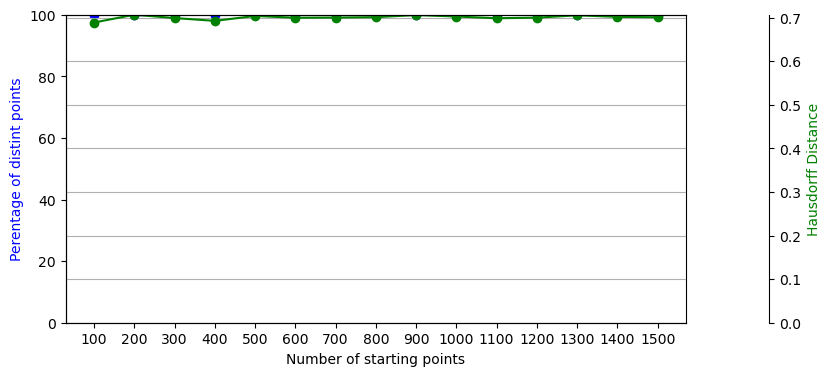

Running for p=  90
551 1000
1225 2000
1963 3000
2729 4000
3633 5000
4460 6000
5470 7000
6316 8000
7202 9000
8095 10000
9067 11000
10041 12000
10929 13000
11931 14000
12921 15000


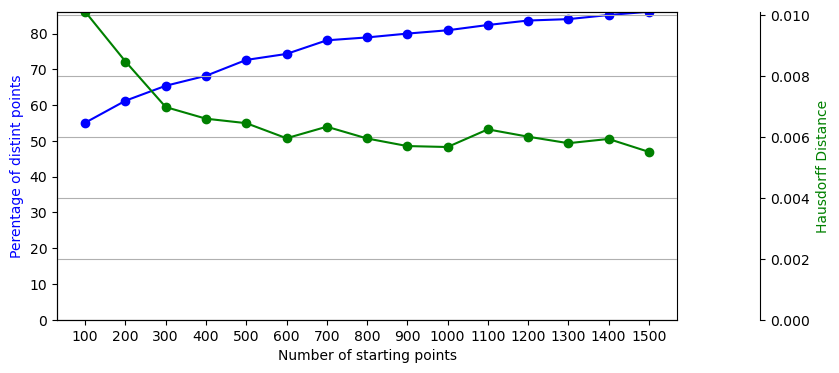

Running for p=  80
575 1000
1202 2000
1822 3000
2490 4000
3231 5000
3973 6000
4773 7000
5570 8000
6423 9000
7342 10000
8204 11000
9201 12000
10015 13000
10896 14000
11710 15000


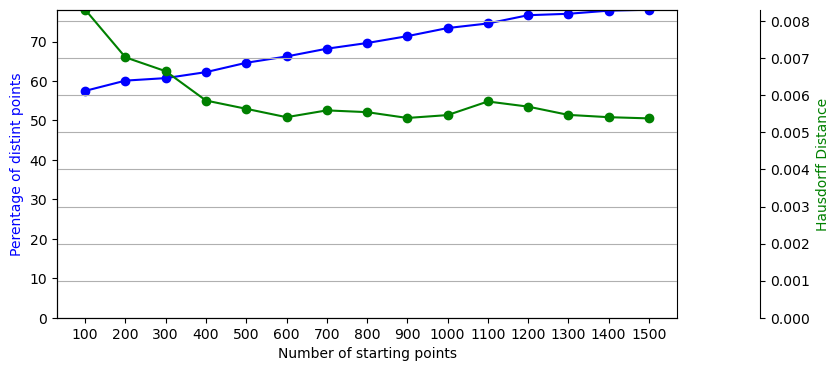

Running for p=  70
604 1000
1291 2000
1972 3000
2661 4000
3381 5000
4108 6000
4845 7000
5631 8000
6377 9000
7119 10000
7970 11000
8838 12000
9779 13000
10577 14000
11517 15000


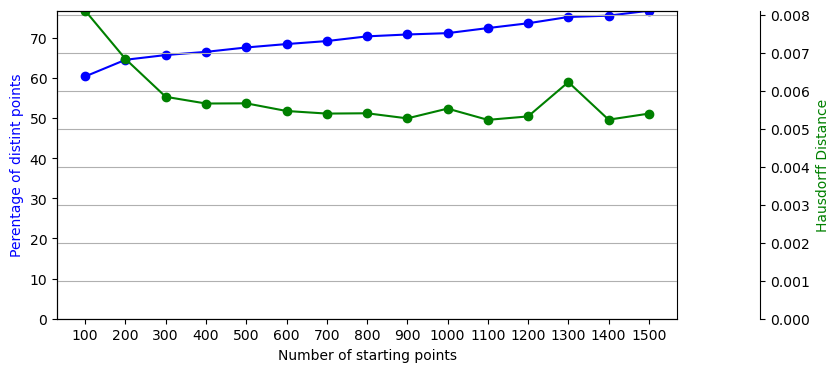

Running for p=  60
672 1000
1396 2000
2134 3000
2914 4000
3667 5000
4408 6000
5164 7000
5983 8000
6713 9000
7475 10000
8282 11000
9087 12000
9914 13000
10716 14000
11586 15000


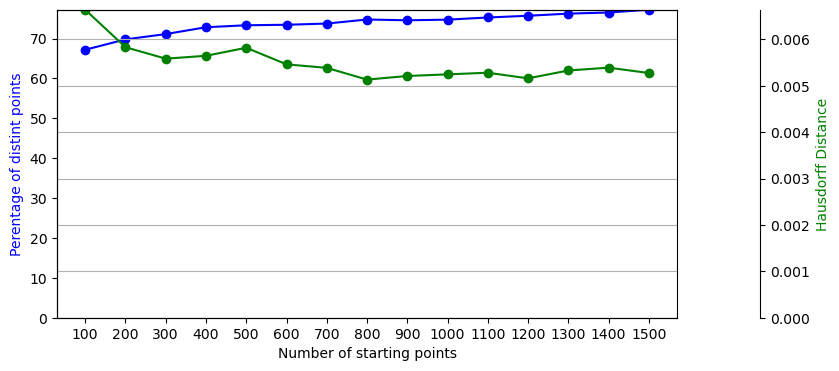

Running for p=  50
712 1000
1483 2000
2306 3000
3130 4000
3923 5000
4761 6000
5575 7000
6353 8000
7228 9000
8028 10000
8833 11000
9744 12000
10522 13000
11341 14000
12225 15000


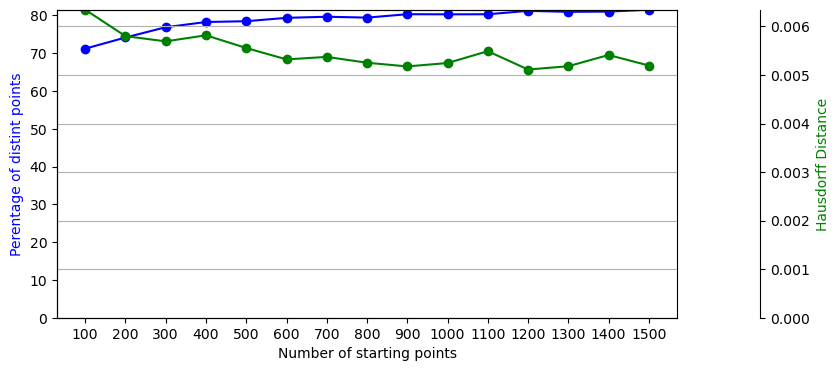

Running for p=  40
736 1000
1568 2000
2437 3000
3307 4000
4194 5000
5022 6000
5928 7000
6813 8000
7687 9000
8566 10000
9447 11000
10309 12000
11244 13000
12080 14000
12949 15000


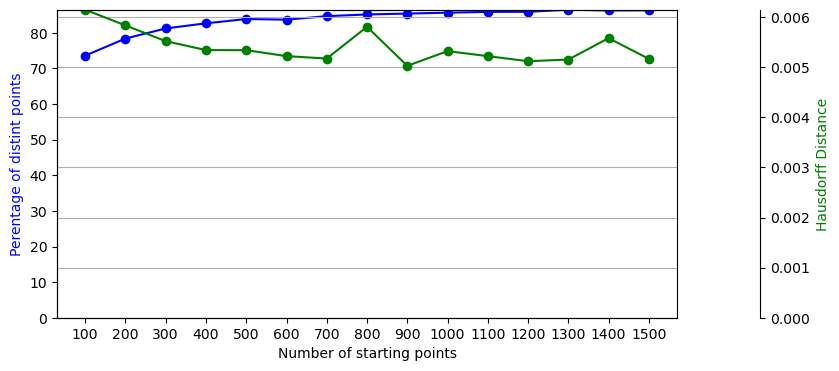

Running for p=  30
753 1000
1653 2000
2557 3000
3435 4000
4407 5000
5313 6000
6238 7000
7146 8000
8060 9000
9010 10000
9941 11000
10859 12000
11793 13000
12678 14000
13641 15000


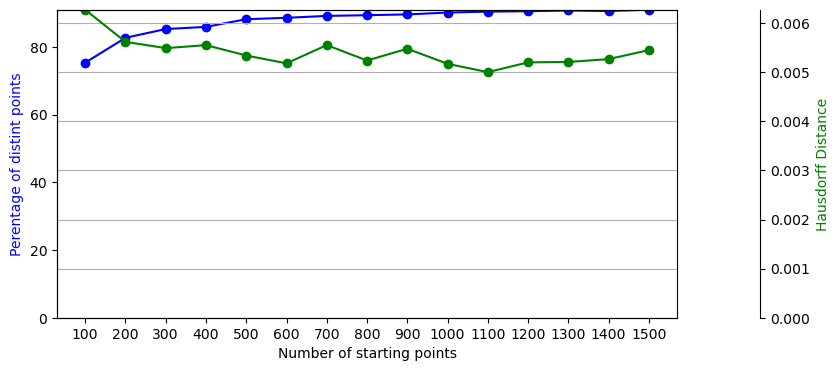

Running for p=  20
764 1000
1696 2000
2618 3000
3600 4000
4553 5000
5530 6000
6479 7000
7413 8000
8387 9000
9356 10000
10280 11000
11293 12000
12240 13000
13189 14000
14204 15000


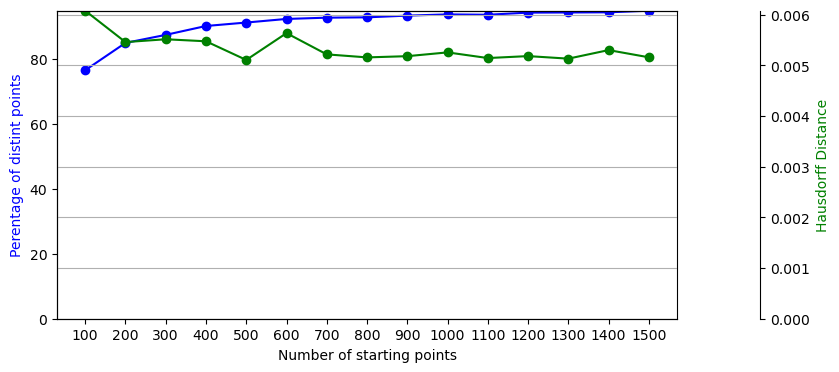

Running for p=  10
727 1000
1737 2000
2680 3000
3690 4000
4654 5000
5634 6000
6610 7000
7643 8000
8649 9000
9583 10000
10549 11000
11558 12000
12537 13000
13564 14000
14543 15000


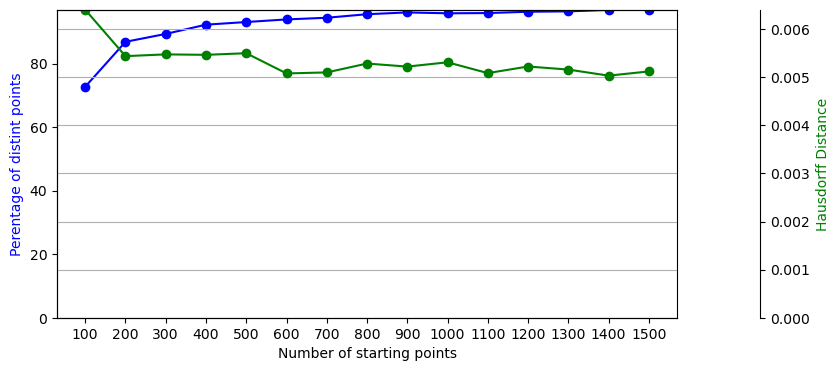

In [15]:
Ex2Res= {10: {
    "pdp": None, "hd": None,
}, 20: {
    "pdp": None, "hd":None,
}, 30: {
    "pdp": None, "hd": None, 
}, 40: {
    "pdp": None, "hd": None, 
}
, 50: {
    "pdp": None, "hd": None, 
}
, 60: {
    "pdp": None, "hd": None, 
}
, 70: {
    "pdp": None, "hd": None, 
}
, 80: {
    "pdp": None, "hd": None, 
}
, 90: {
    "pdp": None, "hd": None, 
}
, 100: {
    "pdp": None, "hd": None, 
}
}

# for p in range(len(percents)):
for p in range(len(percents)-1, -1, -1):
    print("Running for p= ", percents[p])
    main_path = "./percent/"+str(percents[p])+"/Ex2/"
    subfolders = list_subfolders(main_path)

        
    txt_files = list_subfolders(subfolders[0])
    # list_txt_files(subfolders[0])

    titles = [str(100*i) for i in range(1, 16)]

    colors = [
        'blue', 'orange', 'r', 'yellow', 'purple',
        'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
        'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
    ]

    folders= ["./percent/"+str(percents[p])+"/Ex2/N_{}/".format(str(pt)) for pt in nubmer_points_list]
    pdpeia, hdeia, accuracyeia= get_values(folders)
    Ex2Res[percents[p]]["pdp"]= pdpeia
    Ex2Res[percents[p]]["hd"]= hdeia

In [18]:
import json
import numpy as np

def convert(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    raise TypeError(f"Type {type(obj)} not serializable")

with open("Ex2EIA.json", "w") as f:
    json.dump(Ex2Res, f, default=convert)

## Plot

In [19]:
import json

# Load the JSON file
with open("Ex2EIA.json", "r") as f:  # replace "data.json" with your file name
    res = json.load(f)

# Convert keys to integers (optional, makes plotting easier)
res = {int(k): v for k, v in res.items()}

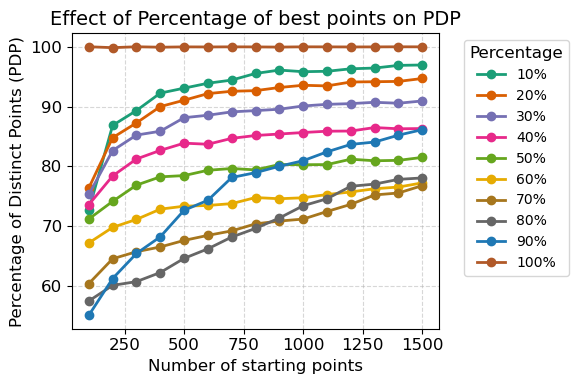

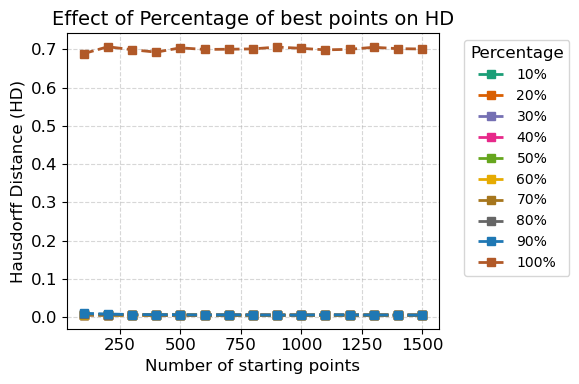

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Data
points = np.arange(100, 1600, 100)
keys = sorted(res.keys())  # ensures percentages are in order

# Publication-style settings
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "lines.linewidth": 2,
    "lines.markersize": 6
})

# Publication-friendly 10-color palette (colorblind-friendly)
colors = [
    '#1b9e77',  # greenish
    '#d95f02',  # orange
    '#7570b3',  # purple
    '#e7298a',  # pink/magenta
    '#66a61e',  # lime green
    '#e6ab02',  # yellow-orange
    '#a6761d',  # brown
    '#666666',  # gray
    '#1f78b4',  # blue
    '#b15928',  # reddish brown
]

# colors = pub_colors_10 #plt.cm.viridis(np.linspace(0, 1, len(keys)))

# ---- PDP Plot ----
fig, ax = plt.subplots(figsize=(6,4))
for i, p in enumerate(keys):
    ax.plot(points, res[p]["pdp"], marker='o', linestyle='-', color=colors[i], label=f'{p}%')
ax.set_xlabel('Number of starting points')
ax.set_ylabel('Percentage of Distinct Points (PDP)')
ax.set_title('Effect of Percentage of best points on PDP')
ax.grid(True, linestyle='--', alpha=0.5)

# Adaptive legend: outside if many lines, inside if few
if len(keys) > 6:
    ax.legend(title='Percentage', bbox_to_anchor=(1.05, 1), loc='upper left')
else:
    ax.legend(title='Percentage', loc='best')

plt.tight_layout()
plt.savefig("Ex2PDP_vs_p.png", dpi=300, bbox_inches='tight')
plt.show()

# ---- HD Plot ----
fig, ax = plt.subplots(figsize=(6,4))
for i, p in enumerate(keys):
    ax.plot(points, res[p]["hd"], marker='s', linestyle='--', color=colors[i], label=f'{p}%')
ax.set_xlabel('Number of starting points')
ax.set_ylabel('Hausdorff Distance (HD)')
ax.set_title('Effect of Percentage of best points on HD')
ax.grid(True, linestyle='--', alpha=0.5)

# Adaptive legend
if len(keys) > 6:
    ax.legend(title='Percentage', bbox_to_anchor=(1.05, 1), loc='upper left')
else:
    ax.legend(title='Percentage', loc='best')

plt.tight_layout()
plt.savefig("Ex2HD_vs_p.png", dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# for (p,h,acc) in zip(pdpeia,hdeia, accuracyeia):
#     print(p, " * ", h, " * ", acc)